### LSTM 

In [53]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import ast
from copy import deepcopy

In [54]:


HORIZON = 72
SEQ_LEN = 48
EPOCHS = 100


df_main = pd.read_csv("final_data.csv")
df_main["datetime"] = pd.to_datetime(df_main["datetime"])

dk = pd.read_csv("hourly_data_Danmark_55.99775695800781_10.0052490234375.csv")
ring = pd.read_csv("hourly_data_Ringsted_56.1740608215332_9.545852661132812.csv")
silk = pd.read_csv("hourly_data_Silkeborg_55.444580078125_11.78314208984375.csv")

for df in [dk, ring, silk]:
    df["date"] = pd.to_datetime(df["date"])

dk = dk.add_prefix("dk_").rename(columns={"dk_date": "datetime"})
ring = ring.add_prefix("ring_").rename(columns={"ring_date": "datetime"})
silk = silk.add_prefix("silk_").rename(columns={"silk_date": "datetime"})

df = df_main.merge(dk, on="datetime", how="left")
df = df.merge(ring, on="datetime", how="left")
df = df.merge(silk, on="datetime", how="left")

df = df.sort_values("datetime")
print("before", len(df))

df["hour"] = df["datetime"].dt.hour

df["lag_1"] = df["value_spot"].shift(1)
df["lag_2"] = df["value_spot"].shift(2)
df["lag_24"] = df["value_spot"].shift(24)

df = df.ffill()



df = pd.get_dummies(df, columns=[c for c in ["zone_prev", "zone"] if c in df.columns], drop_first=True)

# IMPORT
df["import"] = df["import"].apply(ast.literal_eval)
import_expanded = df["import"].apply(pd.Series).add_prefix("import_")

# EXPORT
df["export"] = df["export"].apply(ast.literal_eval)
export_expanded = df["export"].apply(pd.Series).add_prefix("export_")

# Combine everything
df = pd.concat(
    [df.drop(columns=["import", "export"]), import_expanded, export_expanded],
    axis=1
)



df["mix"] = df["mix"].apply(ast.literal_eval)
expanded = df["mix"].apply(pd.Series)
df = pd.concat([df.drop(columns=["mix"]), expanded], axis=1)



df = df.join(df["flows"].apply(pd.Series))

df = df.fillna(0)

df = df.drop(columns=["emissionFactorType", "battery storage", "hydro storage", "flows", "unit_spot", "unit_total_load"])




before 34994


In [55]:
df["value_spot"].describe()

count    34994.000000
mean       149.466225
std        128.188643
min       -440.100000
25%         70.080000
50%        112.870000
75%        193.722500
max        871.000000
Name: value_spot, dtype: float64

In [56]:
for i in range(1, HORIZON + 1):
    df[f"price_t+{i}"] = df["value_spot"].shift(-i)
    df[f"carbon_t+{i}"] = df["carbonIntensity"].shift(-i)

hours = df["hour"].values
df = df.drop(columns=["datetime"], errors="ignore")
df = df.dropna()

target_cols = (
    [f"price_t+{i}" for i in range(1, HORIZON + 1)] +
    [f"carbon_t+{i}" for i in range(1, HORIZON + 1)]
)

X = df.drop(columns=target_cols).values
Y = df[target_cols].values
hours = hours[-len(X):]


split1 = int(0.7 * len(X))
split2 = int(0.85 * len(X))

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
Y_train, Y_val, Y_test = Y[:split1], Y[split1:split2], Y[split2:]
h_train, h_val, h_test = hours[:split1], hours[split1:split2], hours[split2:]


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def create_sequences_12(X, Y, hours, seq_len=48):
    X_seq, Y_seq = [], []

    for i in range(len(X) - seq_len - HORIZON):
        if hours[i + seq_len - 1] != 12:
            continue

        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[i+seq_len])

    return np.array(X_seq), np.array(Y_seq)

X_train, Y_train = create_sequences_12(X_train, Y_train, h_train, SEQ_LEN)
X_val, Y_val = create_sequences_12(X_val, Y_val, h_val, SEQ_LEN)
X_test, Y_test = create_sequences_12(X_test, Y_test, h_test, SEQ_LEN)

/var/folders/47/tm461bpn1bn2r8cqz3v19h7r0000gp/T/ipykernel_42467/4048923525.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"carbon_t+{i}"] = df["carbonIntensity"].shift(-i)
/var/folders/47/tm461bpn1bn2r8cqz3v19h7r0000gp/T/ipykernel_42467/4048923525.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"price_t+{i}"] = df["value_spot"].shift(-i)


In [57]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)


class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, HORIZON * 2)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMModel(X_train.shape[2])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [58]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
counter = 0
best_weights = None
patience = 2

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_loss += criterion(model(Xb), yb).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train: {train_loss:.2f}, Val: {val_loss:.2f}")

model.eval()
preds, actuals = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds.append(model(Xb).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

price_pred = preds[:, :HORIZON]
carbon_pred = preds[:, HORIZON:2*HORIZON]

price_true = actuals[:, :HORIZON]
carbon_true = actuals[:, HORIZON:2*HORIZON]

print("\nFINAL RESULTS")
print(f"Price MAE: {np.mean(np.abs(price_pred - price_true)):.2f}")
print(f"Carbon MAE: {np.mean(np.abs(carbon_pred - carbon_true)):.2f}")


Epoch 1, Train: 689995.40, Val: 39653.14
Epoch 2, Train: 664594.27, Val: 32168.13
Epoch 3, Train: 572283.38, Val: 18651.33
Epoch 4, Train: 434177.02, Val: 8025.28
Epoch 5, Train: 298642.19, Val: 11160.57
Epoch 6, Train: 217990.54, Val: 26896.10
Epoch 7, Train: 196982.60, Val: 37325.01
Epoch 8, Train: 194322.10, Val: 37172.00
Epoch 9, Train: 193491.73, Val: 35606.84
Epoch 10, Train: 192791.59, Val: 35219.52
Epoch 11, Train: 192398.66, Val: 35286.46
Epoch 12, Train: 192818.73, Val: 35064.58
Epoch 13, Train: 192638.77, Val: 35538.03
Epoch 14, Train: 191001.01, Val: 34216.30
Epoch 15, Train: 179576.47, Val: 11796.30
Epoch 16, Train: 155527.31, Val: 8957.71
Epoch 17, Train: 136949.15, Val: 7669.69
Epoch 18, Train: 125397.24, Val: 8071.61
Epoch 19, Train: 118519.23, Val: 7497.23
Epoch 20, Train: 114328.08, Val: 7659.64
Epoch 21, Train: 111187.67, Val: 8051.82
Epoch 22, Train: 109262.77, Val: 7922.27
Epoch 23, Train: 107821.30, Val: 7790.12
Epoch 24, Train: 105639.81, Val: 7701.06
Epoch 25, T

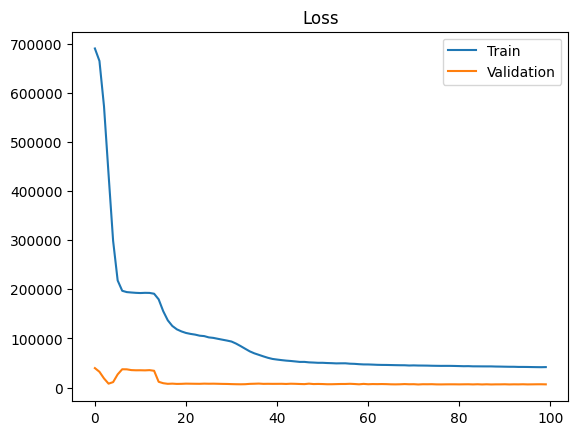

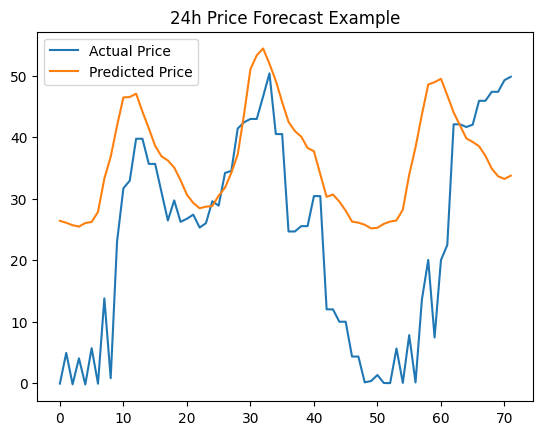

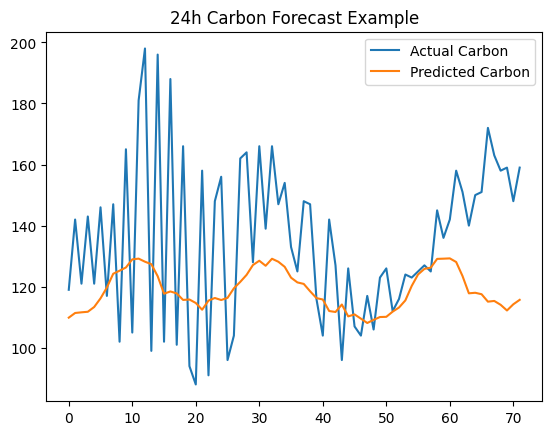

In [59]:
# Loss curves
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()

#example plot
idx = 200

plt.figure()
plt.plot(price_true[idx], label="Actual Price")
plt.plot(price_pred[idx], label="Predicted Price")
plt.legend()
plt.title("24h Price Forecast Example")
plt.show()

plt.figure()
plt.plot(carbon_true[idx], label="Actual Carbon")
plt.plot(carbon_pred[idx], label="Predicted Carbon")
plt.legend()
plt.title("24h Carbon Forecast Example")
plt.show()

In [60]:


HORIZON = 24
SEQ_LEN = 48
EPOCHS = 100


df_main = pd.read_csv("final_data.csv")
df_main["datetime"] = pd.to_datetime(df_main["datetime"])

dk = pd.read_csv("hourly_data_Danmark_55.99775695800781_10.0052490234375.csv")
ring = pd.read_csv("hourly_data_Ringsted_56.1740608215332_9.545852661132812.csv")
silk = pd.read_csv("hourly_data_Silkeborg_55.444580078125_11.78314208984375.csv")

for df in [dk, ring, silk]:
    df["date"] = pd.to_datetime(df["date"])

dk = dk.add_prefix("dk_").rename(columns={"dk_date": "datetime"})
ring = ring.add_prefix("ring_").rename(columns={"ring_date": "datetime"})
silk = silk.add_prefix("silk_").rename(columns={"silk_date": "datetime"})

df = df_main.merge(dk, on="datetime", how="left")
df = df.merge(ring, on="datetime", how="left")
df = df.merge(silk, on="datetime", how="left")

df = df.sort_values("datetime")
print("before", len(df))

df["hour"] = df["datetime"].dt.hour

df["lag_1"] = df["value_spot"].shift(1)
df["lag_2"] = df["value_spot"].shift(2)
df["lag_24"] = df["value_spot"].shift(24)

df = df.ffill()



df = pd.get_dummies(df, columns=[c for c in ["zone_prev", "zone"] if c in df.columns], drop_first=True)

# IMPORT
df["import"] = df["import"].apply(ast.literal_eval)
import_expanded = df["import"].apply(pd.Series).add_prefix("import_")

# EXPORT
df["export"] = df["export"].apply(ast.literal_eval)
export_expanded = df["export"].apply(pd.Series).add_prefix("export_")

# Combine everything
df = pd.concat(
    [df.drop(columns=["import", "export"]), import_expanded, export_expanded],
    axis=1
)



df["mix"] = df["mix"].apply(ast.literal_eval)
expanded = df["mix"].apply(pd.Series)
df = pd.concat([df.drop(columns=["mix"]), expanded], axis=1)



df = df.join(df["flows"].apply(pd.Series))

df = df.fillna(0)

df = df.drop(columns=["emissionFactorType", "battery storage", "hydro storage", "flows", "unit_spot", "unit_total_load"])




df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["weekday_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["weekday_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["month_sin"] = np.sin(2 * np.pi * (df["month"] -1) / 12)
df["month_cos"] = np.cos(2 * np.pi * (df["month"] -1)/ 12)

before 34994


In [61]:
for i in range(1, HORIZON + 1):
    df[f"price_t+{i}"] = df["value_spot"].shift(-i)

hours = df["hour"].values
df = df.drop(columns=["datetime"], errors="ignore")
df = df.dropna()

target_cols = (
    [f"price_t+{i}" for i in range(1, HORIZON + 1)] 
)

drop_cols = ["hour", "day_of_week","month"]

X = df.drop(columns=target_cols+drop_cols).values
Y = df[target_cols].values
hours = hours[-len(X):]


split1 = int(0.7 * len(X))
split2 = int(0.85 * len(X))

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
Y_train, Y_val, Y_test = Y[:split1], Y[split1:split2], Y[split2:]
h_train, h_val, h_test = hours[:split1], hours[split1:split2], hours[split2:]


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def create_sequences_12(X, Y, hours, seq_len=48):
    X_seq, Y_seq = [], []

    for i in range(len(X) - seq_len - HORIZON):
        if hours[i + seq_len - 1] != 12:
            continue

        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[i+seq_len])

    return np.array(X_seq), np.array(Y_seq)

X_train, Y_train = create_sequences_12(X_train, Y_train, h_train, SEQ_LEN)
X_val, Y_val = create_sequences_12(X_val, Y_val, h_val, SEQ_LEN)
X_test, Y_test = create_sequences_12(X_test, Y_test, h_test, SEQ_LEN)

In [62]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)


class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 48, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(48, 128),
            nn.ReLU(),
            nn.Linear(128, 24)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMModel(X_train.shape[2])

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [63]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
counter = 0
best_weights = None
patience = 15

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_loss += criterion(model(Xb), yb).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train: {train_loss:.2f}, Val: {val_loss:.2f}")


    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break


    if best_weights is not None:
        model.load_state_dict(best_weights)

model.eval()
preds, actuals = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds.append(model(Xb).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

price_pred = preds[:, :24]
carbon_pred = preds[:, 24:]

price_true = actuals[:, :24]
carbon_true = actuals[:, 24:]

print("\nFINAL RESULTS")
print(f"Price MAE: {np.mean(np.abs(price_pred - price_true)):.2f}")
print(f"Carbon MAE: {np.mean(np.abs(carbon_pred - carbon_true)):.2f}")


Epoch 1, Train: 2760.72, Val: 302.45
Epoch 2, Train: 2736.24, Val: 291.26
Epoch 3, Train: 2653.39, Val: 264.00
Epoch 4, Train: 2498.89, Val: 224.79
Epoch 5, Train: 2291.46, Val: 179.17
Epoch 6, Train: 2053.08, Val: 136.85
Epoch 7, Train: 1821.48, Val: 126.59
Epoch 8, Train: 1651.85, Val: 172.37
Epoch 9, Train: 1578.81, Val: 218.68
Epoch 10, Train: 1561.95, Val: 249.98
Epoch 11, Train: 1551.76, Val: 259.57
Epoch 12, Train: 1549.36, Val: 260.59
Epoch 13, Train: 1537.64, Val: 240.51
Epoch 14, Train: 1391.82, Val: 207.25
Epoch 15, Train: 1251.40, Val: 112.73
Epoch 16, Train: 1086.42, Val: 103.48
Epoch 17, Train: 974.28, Val: 101.66
Epoch 18, Train: 887.27, Val: 96.59
Epoch 19, Train: 814.50, Val: 99.06
Epoch 20, Train: 758.11, Val: 98.06
Epoch 21, Train: 704.32, Val: 97.12
Epoch 22, Train: 679.42, Val: 95.65
Epoch 23, Train: 650.76, Val: 103.42
Epoch 24, Train: 629.37, Val: 99.94
Epoch 25, Train: 611.01, Val: 97.86
Epoch 26, Train: 598.19, Val: 99.99
Epoch 27, Train: 588.90, Val: 103.43
Ep

/Users/ludviglindmark/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/Kandidat/Advanced BA/Advanced_business_analytics/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ludviglindmark/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/Kandidat/Advanced BA/Advanced_business_analytics/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


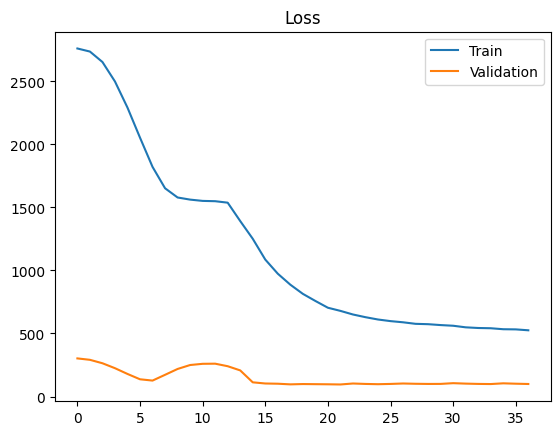

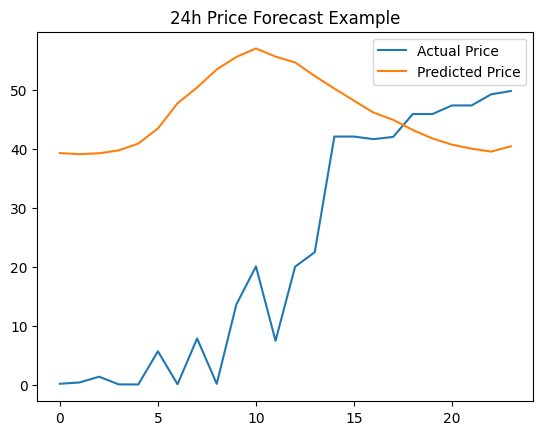

In [64]:
# Loss curves
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()

#example plot
idx = 200

plt.figure()
plt.plot(price_true[idx], label="Actual Price")
plt.plot(price_pred[idx], label="Predicted Price")
plt.legend()
plt.title("24h Price Forecast Example")
plt.show()


In [65]:
for i in range(1, HORIZON + 1):
    df[f"carbon_t+{i}"] = df["carbonIntensity"].shift(-i)

hours = df["hour"].values
df = df.drop(columns=["datetime"], errors="ignore")
df = df.dropna()

target_cols = (
    [f"carbon_t+{i}" for i in range(1, HORIZON + 1)] 
)

drop_cols = ["hour", "day_of_week","month"]

X = df.drop(columns=target_cols+drop_cols).values
Y = df[target_cols].values
hours = hours[-len(X):]


split1 = int(0.7 * len(X))
split2 = int(0.85 * len(X))

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
Y_train, Y_val, Y_test = Y[:split1], Y[split1:split2], Y[split2:]
h_train, h_val, h_test = hours[:split1], hours[split1:split2], hours[split2:]


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def create_sequences_12(X, Y, hours, seq_len=48):
    X_seq, Y_seq = [], []

    for i in range(len(X) - seq_len - HORIZON):
        if hours[i + seq_len - 1] != 12:
            continue

        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[i+seq_len])

    return np.array(X_seq), np.array(Y_seq)

X_train, Y_train = create_sequences_12(X_train, Y_train, h_train, SEQ_LEN)
X_val, Y_val = create_sequences_12(X_val, Y_val, h_val, SEQ_LEN)
X_test, Y_test = create_sequences_12(X_test, Y_test, h_test, SEQ_LEN)

/var/folders/47/tm461bpn1bn2r8cqz3v19h7r0000gp/T/ipykernel_42467/863059002.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"carbon_t+{i}"] = df["carbonIntensity"].shift(-i)


In [66]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)


class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 48, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(48, 256),
            nn.ReLU(),
            nn.Linear(256, 24)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMModel(X_train.shape[2])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [67]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
counter = 0
best_weights = None
patience = 2

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_loss += criterion(model(Xb), yb).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train: {train_loss:.2f}, Val: {val_loss:.2f}")


    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break


    if best_weights is not None:
        model.load_state_dict(best_weights)

model.eval()
preds, actuals = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds.append(model(Xb).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

carbon_pred = preds[:, :24]

carbon_true = actuals[:, :24]

print("\nFINAL RESULTS")
print(f"Carbon MAE: {np.mean(np.abs(carbon_pred - carbon_true)):.2f}")


Epoch 1, Train: 572295.63, Val: 47010.47
Epoch 2, Train: 554570.88, Val: 40906.79
Epoch 3, Train: 487242.20, Val: 27973.92
Epoch 4, Train: 376914.12, Val: 13763.89
Epoch 5, Train: 252922.32, Val: 5987.52
Epoch 6, Train: 154869.24, Val: 9685.47
Epoch 7, Train: 107791.81, Val: 20335.00
Early stopping

FINAL RESULTS
Carbon MAE: 73.87


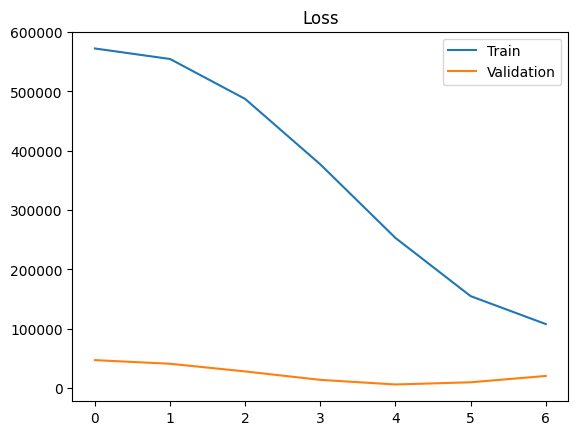

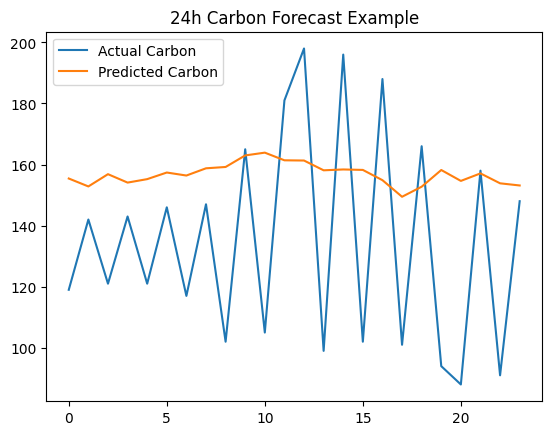

In [68]:
# Loss curves
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()

#example plot
idx = 200

plt.figure()
plt.plot(carbon_true[idx], label="Actual Carbon")
plt.plot(carbon_pred[idx], label="Predicted Carbon")
plt.legend()
plt.title("24h Carbon Forecast Example")
plt.show()

## Model for zone 1 and only price
This section covers only the model for one of the zones and price


In [69]:


HORIZON = 72
SEQ_LEN = 48
EPOCHS = 1000


df_main = pd.read_csv("final_data.csv")
df_main["datetime"] = pd.to_datetime(df_main["datetime"])

dk = pd.read_csv("hourly_data_Danmark_55.99775695800781_10.0052490234375.csv")
ring = pd.read_csv("hourly_data_Ringsted_56.1740608215332_9.545852661132812.csv")
silk = pd.read_csv("hourly_data_Silkeborg_55.444580078125_11.78314208984375.csv")

for df in [dk, ring, silk]:
    df["date"] = pd.to_datetime(df["date"])

dk = dk.add_prefix("dk_").rename(columns={"dk_date": "datetime"})
ring = ring.add_prefix("ring_").rename(columns={"ring_date": "datetime"})
silk = silk.add_prefix("silk_").rename(columns={"silk_date": "datetime"})

df = df_main.merge(dk, on="datetime", how="left")
df = df.merge(ring, on="datetime", how="left")
df = df.merge(silk, on="datetime", how="left")

df = df.sort_values("datetime")
print("before", len(df))

df_z1 = df[df["zone"] == "DK-DK1"].copy()

df_z1["hour"] = df_z1["datetime"].dt.hour

df_z1["lag_1"] = df_z1["value_spot"].shift(1)
df_z1["lag_2"] = df_z1["value_spot"].shift(2)
df_z1["lag_24"] = df_z1["value_spot"].shift(24)
df_z1["lag_168"] = df_z1["value_spot"].shift(24*7)

df_z1 = df_z1.ffill()




# IMPORT
df_z1["import"] = df_z1["import"].apply(ast.literal_eval)
import_expanded = df_z1["import"].apply(pd.Series).add_prefix("import_")

# EXPORT
df_z1["export"] = df_z1["export"].apply(ast.literal_eval)
export_expanded = df_z1["export"].apply(pd.Series).add_prefix("export_")

# Combine everything
df_z1 = pd.concat(
    [df_z1.drop(columns=["import", "export"]), import_expanded, export_expanded],
    axis=1
)



df_z1["mix"] = df_z1["mix"].apply(ast.literal_eval)
expanded = df_z1["mix"].apply(pd.Series)
df_z1 = pd.concat([df_z1.drop(columns=["mix"]), expanded], axis=1)



df_z1 = df_z1.join(df_z1["flows"].apply(pd.Series))

df_z1 = df_z1.fillna(0)

df_z1 = df_z1.drop(columns=["emissionFactorType", "battery storage", "hydro storage", "flows", "unit_spot", "unit_total_load"])

df_z1["rolling_mean_24"] = df_z1["value_spot"].rolling(window=24).mean()


df_z1["hour_sin"] = np.sin(2 * np.pi * df_z1["hour"] / 24)
df_z1["hour_cos"] = np.cos(2 * np.pi * df_z1["hour"] / 24)

df_z1["weekday_sin"] = np.sin(2 * np.pi * df_z1["day_of_week"] / 7)
df_z1["weekday_cos"] = np.cos(2 * np.pi * df_z1["day_of_week"] / 7)

df_z1["month_sin"] = np.sin(2 * np.pi * (df_z1["month"] -1) / 12)
df_z1["month_cos"] = np.cos(2 * np.pi * (df_z1["month"] -1)/ 12)


before 34994


In [70]:
for i in range(1, HORIZON + 1):
    df_z1[f"price_t+{i}"] = df_z1["value_spot"].shift(-i)

df_z1 = df_z1.drop(columns=["datetime"], errors="ignore")
df_z1 = df_z1.dropna()

hours = df_z1["hour"].values

target_cols = [f"price_t+{i}" for i in range(1, HORIZON + 1)]

drop_cols = ["hour", "day_of_week", "month", "zone"]

X = df_z1.drop(columns=target_cols + drop_cols).values
Y = df_z1[target_cols].values


split1 = int(0.7 * len(X))
split2 = int(0.85 * len(X))

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
Y_train, Y_val, Y_test = Y[:split1], Y[split1:split2], Y[split2:]
h_train, h_val, h_test = hours[:split1], hours[split1:split2], hours[split2:]


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def create_sequences_12(X, Y, hours, seq_len=48):
    X_seq, Y_seq = [], []

    for i in range(len(X) - seq_len):
        end_idx = i + seq_len - 1

        if hours[end_idx] != 12:
            continue

        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[end_idx])

    return np.array(X_seq), np.array(Y_seq)

X_train, Y_train = create_sequences_12(X_train, Y_train, h_train, SEQ_LEN)
X_val, Y_val = create_sequences_12(X_val, Y_val, h_val, SEQ_LEN)
X_test, Y_test = create_sequences_12(X_test, Y_test, h_test, SEQ_LEN)

In [71]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)


import LSTM_PRICE
model = LSTM_PRICE.LSTMModelPrice(input_dim=X_train.shape[2], HORIZON=HORIZON)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [72]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
counter = 0
best_weights = None
patience = 100

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_loss += criterion(model(Xb), yb).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train: {train_loss:.2f}, Val: {val_loss:.2f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break


    if best_weights is not None:
        model.load_state_dict(best_weights)

model.eval()
preds, actuals = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds.append(model(Xb).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

price_pred = preds[:, :]

price_true = actuals[:, :]

print("\nFINAL RESULTS")
print(f"Price MAE: {np.mean(np.abs(price_pred - price_true)):.2f}")
print(f"Validation MAE: {best_val_loss:.2f}")


Epoch 1, Train: 1496.94, Val: 169.34
Epoch 2, Train: 1490.62, Val: 167.94
Epoch 3, Train: 1480.35, Val: 162.07
Epoch 4, Train: 1443.64, Val: 151.75
Epoch 5, Train: 1386.90, Val: 136.97
Epoch 6, Train: 1312.16, Val: 118.87
Epoch 7, Train: 1215.52, Val: 98.24
Epoch 8, Train: 1100.84, Val: 77.88
Epoch 9, Train: 982.13, Val: 66.66
Epoch 10, Train: 876.45, Val: 78.37
Epoch 11, Train: 814.17, Val: 104.15
Epoch 12, Train: 790.61, Val: 127.49
Epoch 13, Train: 780.59, Val: 140.64
Epoch 14, Train: 779.82, Val: 144.66
Epoch 15, Train: 777.33, Val: 143.92
Epoch 16, Train: 775.66, Val: 141.58
Epoch 17, Train: 773.95, Val: 137.15
Epoch 18, Train: 773.92, Val: 135.46
Epoch 19, Train: 772.78, Val: 135.15
Epoch 20, Train: 774.76, Val: 133.48
Epoch 21, Train: 773.56, Val: 134.67
Epoch 22, Train: 774.64, Val: 134.75
Epoch 23, Train: 773.28, Val: 135.30
Epoch 24, Train: 776.01, Val: 136.02
Epoch 25, Train: 773.53, Val: 136.39
Epoch 26, Train: 774.47, Val: 135.28
Epoch 27, Train: 775.15, Val: 135.01
Epoch 

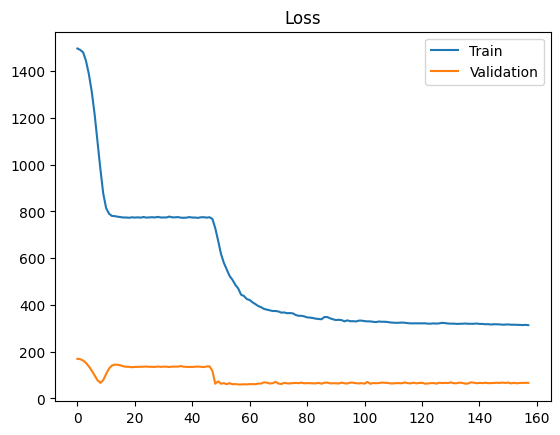

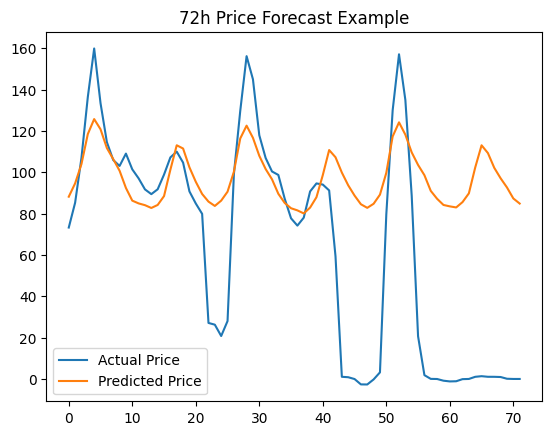

In [73]:
# Loss curves
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()

#example plot
idx = 10

plt.figure()
plt.plot(price_true[idx], label="Actual Price")
plt.plot(price_pred[idx], label="Predicted Price")
plt.legend()
plt.title("72h Price Forecast Example")
plt.show()


In [74]:
print(model.state_dict())

OrderedDict({'lstm.weight_ih_l0': tensor([[ 0.0230,  0.1156,  0.0463,  ...,  0.1619,  0.0237, -0.0327],
        [-0.0369,  0.0556,  0.1618,  ..., -0.0064, -0.1508,  0.0181],
        [ 0.0037,  0.1648, -0.2199,  ...,  0.0485,  0.0347,  0.0529],
        ...,
        [-0.1885,  0.0908, -0.1068,  ..., -0.0755, -0.0348,  0.0669],
        [-0.0353, -0.0012,  0.0891,  ..., -0.1640,  0.0601,  0.1682],
        [ 0.2308, -0.0669,  0.2207,  ...,  0.1787,  0.1485, -0.0084]]), 'lstm.weight_hh_l0': tensor([[-0.2021,  0.0890, -0.0706,  ..., -0.1568, -0.1264,  0.1397],
        [-0.1171, -0.0070,  0.0634,  ..., -0.0115, -0.1453,  0.1251],
        [-0.1116, -0.1877, -0.1148,  ..., -0.0752,  0.0987, -0.1198],
        ...,
        [ 0.0494, -0.2061,  0.0765,  ...,  0.1081,  0.2262, -0.1551],
        [-0.1496, -0.1824, -0.1162,  ...,  0.0119, -0.0565,  0.0751],
        [ 0.1199,  0.0332,  0.0597,  ..., -0.0250,  0.0308, -0.0176]]), 'lstm.bias_ih_l0': tensor([ 0.0685,  0.0900,  0.1263,  0.0791, -0.1515,  0.

In [82]:
example_input = X_train[0:1]  # Shape (1, SEQ_LEN, num_features)
print("Example input shape:", example_input.shape)
print("Example input:", example_input)
example_input_list = example_input.tolist()
print("Example input as list:", example_input_list)

Example input shape: (1, 48, 72)
Example input: [[[-1.00784626  0.12813035  0.67283684 ...  0.87578023 -0.25531973
    1.29041448]
  [-0.81727658  0.32551642  0.75520352 ...  0.87578023 -0.25531973
    1.29041448]
  [-0.72055861  0.61918838  0.54340349 ...  0.87578023 -0.25531973
    1.29041448]
  ...
  [-0.15855078  2.04181238  0.69637018 ...  0.87578023 -0.25531973
    1.29041448]
  [-0.19265195  1.8540549   0.8375702  ...  0.87578023 -0.25531973
    1.29041448]
  [-0.22418083  1.8083191   0.79050353 ...  0.87578023 -0.25531973
    1.29041448]]]
Example input as list: [[[-1.0078462574033453, 0.12813034554290267, 0.6728368439821811, 0.21739639850631295, -0.6278420559723757, -0.6548112072810136, -1.2264391746164365, -0.5685200444130973, -0.26265871043525, -0.5740094144982479, -0.675371833784339, 0.3728512534081944, 0.25114305112096097, 0.35532332403029204, -0.6614895958378073, -0.42041753439655427, -0.6960265572228946, -0.5802301006988433, -0.5842346675454559, -0.5883532323711849, -0.6

In [84]:
import pickle

with open("lstm_model.pickle", "wb") as f:
    pickle.dump({
        "model_state": model.state_dict(),
        "scaler": scaler,
        "input_dim": X_train.shape[2],
        "features": df_z1.drop(columns=target_cols + drop_cols).columns.tolist(),
        "HORIZON": HORIZON,
        "Example_input": example_input_list
    }, f)

In [ ]:
with open("lstm_model.pickle", "rb") as f:
    data = pickle.load(f)
    print(data.keys())

print(data["model"])

dict_keys(['model_state', 'scaler', 'input_dim', 'features', 'HORIZON'])


KeyError: 'model'